In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
!pip install acnportal

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 2.8 MB/s eta 0:00:00a 0:00:01


In [6]:
from acnportal.acndata import DataClient
from tqdm import tqdm

client = DataClient(API_TOKEN)

data = []

for session in tqdm(client.get_sessions(site='caltech')):
    data.append(session)

print("Total sessions:", len(data))

20300it [34:15,  9.88it/s]


JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [7]:
import pandas as pd

df = pd.json_normalize(data)

print(df.shape)
df.head()

(20300, 13)


,_id,userInputs,sessionID,stationID,spaceID,siteID,clusterID,connectionTime,disconnectTime,kWhDelivered,doneChargingTime,timezone,userID
0,5bc90cb9f9af8b0d7fe77cd2,None,2_39_78_362_2018-04-25 11:08:04.400812,2-39-78-362,CA-496,0002,0039,2018-04-25 04:08:04-07:00,2018-04-25 06:20:10-07:00,7.932,2018-04-25 06:21:10-07:00,America/Los_Angeles,None
1,5bc90cb9f9af8b0d7fe77cd3,None,2_39_95_27_2018-04-25 13:45:09.617470,2-39-95-27,CA-319,0002,0039,2018-04-25 06:45:10-07:00,2018-04-25 17:56:16-07:00,10.013,2018-04-25 09:44:15-07:00,America/Los_Angeles,None
2,5bc90cb9f9af8b0d7fe77cd4,None,2_39_79_380_2018-04-25 13:45:49.962001,2-39-79-380,CA-489,0002,0039,2018-04-25 06:45:50-07:00,2018-04-25 16:04:45-07:00,5.257,2018-04-25 07:51:44-07:00,America/Los_Angeles,None
3,5bc90cb9f9af8b0d7fe77cd5,None,2_39_79_379_2018-04-25 14:37:06.460772,2-39-79-379,CA-327,0002,0039,2018-04-25 07:37:06-07:00,2018-04-25 16:55:34-07:00,5.177,2018-04-25 09:05:22-07:00,America/Los_Angeles,None
4,5bc90cb9f9af8b0d7fe77cd6,None,2_39_79_381_2018-04-25 14:40:33.638896,2-39-79-381,CA-490,0002,0039,2018-04-25 07:40:34-07:00,2018-04-25 16:03:12-07:00,10.119,2018-04-25 10:40:30-07:00,America/Los_Angeles,None


In [8]:
print(df.columns.tolist())

['_id', 'userInputs', 'sessionID', 'stationID', 'spaceID', 'siteID', 'clusterID', 'connectionTime', 'disconnectTime', 'kWhDelivered', 'doneChargingTime', 'timezone', 'userID']


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20300 entries, 0 to 20299
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype                              
---  ------            --------------  -----                              
 0   _id               20300 non-null  object                             
 1   userInputs        6863 non-null   object                             
 2   sessionID         20300 non-null  object                             
 3   stationID         20300 non-null  object                             
 4   spaceID           20300 non-null  object                             
 5   siteID            20300 non-null  object                             
 6   clusterID         20300 non-null  object                             
 7   connectionTime    20300 non-null  datetime64[ns, America/Los_Angeles]
 8   disconnectTime    20300 non-null  datetime64[ns, America/Los_Angeles]
 9   kWhDelivered      20300 non-null  float64                    

In [10]:
df.to_csv("acn_caltech.csv", index=False)

In [11]:
from acnportal.acndata import DataClient
from tqdm import tqdm

client = DataClient(API_TOKEN)

data = []

for session in tqdm(client.get_sessions(site='jpl')):
    data.append(session)

print("Total sessions:", len(data))

11600it [14:41, 13.16it/s]


JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [13]:
import pandas as pd

df1 = pd.json_normalize(data)

print(df.shape)
df1.head()

(11600, 13)


,_id,userInputs,sessionID,stationID,spaceID,siteID,clusterID,connectionTime,disconnectTime,kWhDelivered,doneChargingTime,timezone,userID
0,5c36621bf9af8b4639a8e0b4,None,1_1_179_800_2018-09-05 11:04:12.876087,1-1-179-800,AG-3F32,0001,0001,2018-09-05 04:04:13-07:00,2018-09-05 12:09:35-07:00,9.583,NaT,America/Los_Angeles,None
1,5c36621bf9af8b4639a8e0b5,"[{'userID': 333, 'milesRequested': 20, 'WhPerM...",1_1_179_794_2018-09-05 11:08:08.945820,1-1-179-794,AG-3F20,0001,0001,2018-09-05 04:08:09-07:00,2018-09-05 07:09:02-07:00,7.114,NaT,America/Los_Angeles,000000333
2,5c36621bf9af8b4639a8e0b6,"[{'userID': 371, 'milesRequested': 20, 'WhPerM...",1_1_179_797_2018-09-05 12:35:14.070250,1-1-179-797,AG-3F23,0001,0001,2018-09-05 05:35:14-07:00,2018-09-05 17:30:12-07:00,11.774,NaT,America/Los_Angeles,000000371
3,5c36621bf9af8b4639a8e0b7,"[{'userID': 405, 'milesRequested': 20, 'WhPerM...",1_1_179_781_2018-09-05 12:51:31.050539,1-1-179-781,AG-3F31,0001,0001,2018-09-05 05:51:31-07:00,2018-09-05 15:32:58-07:00,6.280,NaT,America/Los_Angeles,000000405
4,5c36621bf9af8b4639a8e0b8,"[{'userID': 368, 'milesRequested': 20, 'WhPerM...",1_1_179_787_2018-09-05 13:08:27.901538,1-1-179-787,AG-3F16,0001,0001,2018-09-05 06:08:28-07:00,2018-09-05 16:32:52-07:00,7.022,NaT,America/Los_Angeles,000000368


In [14]:
df1.to_csv("acn_jpl.csv", index=False)

In [15]:
import pandas as pd

caltech_df = pd.read_csv('/kaggle/working/acn_caltech.csv')
jpl_df = pd.read_csv('/kaggle/working/acn_jpl.csv')

caltech_df['site'] = 'caltech'
jpl_df['site'] = 'jpl'

acn_df = pd.concat([caltech_df, jpl_df], ignore_index=True)

print(acn_df.shape)

(31900, 14)


In [16]:
acn_df.to_csv('acn_combined.csv', index=False)

In [17]:
acn_df.info()
print(acn_df.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31900 entries, 0 to 31899
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   _id               31900 non-null  object 
 1   userInputs        16928 non-null  object 
 2   sessionID         31900 non-null  object 
 3   stationID         31900 non-null  object 
 4   spaceID           31900 non-null  object 
 5   siteID            31900 non-null  int64  
 6   clusterID         31900 non-null  int64  
 7   connectionTime    31900 non-null  object 
 8   disconnectTime    31900 non-null  object 
 9   kWhDelivered      31900 non-null  float64
 10  doneChargingTime  30597 non-null  object 
 11  timezone          31900 non-null  object 
 12  userID            16928 non-null  float64
 13  site              31900 non-null  object 
dtypes: float64(2), int64(2), object(10)
memory usage: 3.4+ MB
['_id', 'userInputs', 'sessionID', 'stationID', 'spaceID', 'siteID', 'cluste

In [18]:
# converting to timestamps
acn_df['connectionTime'] = pd.to_datetime(acn_df['connectionTime'])
acn_df['disconnectTime'] = pd.to_datetime(acn_df['disconnectTime'])
acn_df['doneChargingTime'] = pd.to_datetime(acn_df['doneChargingTime'])

/tmp/ipykernel_58/3966854988.py:2: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  acn_df['connectionTime'] = pd.to_datetime(acn_df['connectionTime'])
/tmp/ipykernel_58/3966854988.py:3: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  acn_df['disconnectTime'] = pd.to_datetime(acn_df['disconnectTime'])
/tmp/ipykernel_58/3966854988.py:4: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `u

In [22]:
acn_df[['connectionTime','disconnectTime','doneChargingTime']].head()
print(acn_df['connectionTime'].dtype)
print(acn_df['disconnectTime'].dtype)
print(acn_df['doneChargingTime'].dtype)
acn_df['connectionTime'] = pd.to_datetime(
    acn_df['connectionTime'],
    errors='coerce',
    utc=True
)

acn_df['disconnectTime'] = pd.to_datetime(
    acn_df['disconnectTime'],
    errors='coerce',
    utc=True
)

acn_df['doneChargingTime'] = pd.to_datetime(
    acn_df['doneChargingTime'],
    errors='coerce',
    utc=True
)

datetime64[ns, UTC]
datetime64[ns, UTC]
datetime64[ns, UTC]


In [23]:
acn_df[['connectionTime','disconnectTime','doneChargingTime']].dtypes

connectionTime      datetime64[ns, UTC]
disconnectTime      datetime64[ns, UTC]
doneChargingTime    datetime64[ns, UTC]
dtype: object

In [24]:
acn_df['session_duration_hr'] = (
    acn_df['disconnectTime'] - acn_df['connectionTime']
).dt.total_seconds() / 3600

In [25]:
# actual charging duration
acn_df['doneChargingTime'] = acn_df['doneChargingTime'].fillna(
    acn_df['disconnectTime']
)
acn_df['charging_duration_hr'] = (
    acn_df['doneChargingTime'] - acn_df['connectionTime']
).dt.total_seconds() / 3600

In [26]:
# utilization ratio
acn_df['utilization_ratio'] = (
    acn_df['charging_duration_hr']
    / acn_df['session_duration_hr']
)

In [27]:
# Baseline revenue
acn_df['baseline_revenue'] = acn_df['kWhDelivered'] * 15

In [28]:
# time features
acn_df['hour'] = acn_df['connectionTime'].dt.hour
acn_df['day_of_week'] = acn_df['connectionTime'].dt.dayofweek
acn_df['month'] = acn_df['connectionTime'].dt.month
acn_df['day'] = acn_df['connectionTime'].dt.day
acn_df['weekend'] = acn_df['day_of_week'].isin([5,6]).astype(int)

In [29]:
hourly_sessions = acn_df.groupby(
    pd.Grouper(key='connectionTime', freq='H')
).size().reset_index(name='num_sessions')
hourly_sessions['congestion_score'] = (
    hourly_sessions['num_sessions']
    / hourly_sessions['num_sessions'].max()
)

/tmp/ipykernel_58/3806910800.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  pd.Grouper(key='connectionTime', freq='H')


In [30]:
hourly_demand = acn_df.groupby(
    pd.Grouper(key='connectionTime', freq='H')
).agg({
    'kWhDelivered':'sum',
    'sessionID':'count',
    'utilization_ratio':'mean',
    'baseline_revenue':'sum'
}).reset_index()
hourly_demand.rename(columns={
    'sessionID':'num_sessions'
}, inplace=True)

/tmp/ipykernel_58/249679472.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  pd.Grouper(key='connectionTime', freq='H')


In [31]:
hourly_demand['hour'] = hourly_demand['connectionTime'].dt.hour
hourly_demand['day_of_week'] = hourly_demand['connectionTime'].dt.dayofweek
hourly_demand['month'] = hourly_demand['connectionTime'].dt.month
hourly_demand['weekend'] = (
    hourly_demand['day_of_week'].isin([5,6]).astype(int)
)

In [32]:
hourly_demand.head()

hourly_demand.shape

hourly_demand.describe()

,kWhDelivered,num_sessions,utilization_ratio,baseline_revenue,hour,day_of_week,month,weekend
count,9752.000000,9752.000000,6490.000000,9752.000000,9752.000000,9752.000000,9752.000000,9752.000000
mean,35.048566,3.271124,0.704146,525.728496,11.502461,2.999180,6.368950,0.285480
std,71.146878,5.364101,0.230920,1067.203169,6.920546,1.999487,3.304971,0.451666
min,0.000000,0.000000,-2.210151,0.000000,0.000000,0.000000,1.000000,0.000000
25%,0.000000,0.000000,0.544026,0.000000,6.000000,1.000000,4.000000,0.000000
50%,12.175000,1.000000,0.715409,182.625000,12.000000,3.000000,6.000000,0.000000
75%,38.182000,4.000000,0.904362,572.730000,17.000000,5.000000,9.000000,1.000000
max,647.395000,46.000000,1.792245,9710.925000,23.000000,6.000000,12.000000,1.000000


In [33]:
print("Negative utilization rows:",
      (acn_df['utilization_ratio'] < 0).sum())

print("Utilization > 1 rows:",
      (acn_df['utilization_ratio'] > 1).sum())

Negative utilization rows: 23
Utilization > 1 rows: 1073


In [34]:
acn_df['utilization_ratio'] = acn_df['utilization_ratio'].clip(0, 1)
hourly_demand = acn_df.groupby(
    pd.Grouper(key='connectionTime', freq='H')
).agg({
    'kWhDelivered':'sum',
    'sessionID':'count',
    'utilization_ratio':'mean',
    'baseline_revenue':'sum'
}).reset_index()

hourly_demand.rename(
    columns={'sessionID':'num_sessions'},
    inplace=True
)
hourly_demand['utilization_ratio'].describe()

/tmp/ipykernel_58/415479557.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  pd.Grouper(key='connectionTime', freq='H')


count    6490.000000
mean        0.704297
std         0.226533
min         0.000000
25%         0.544026
50%         0.715304
75%         0.903820
max         1.000000
Name: utilization_ratio, dtype: float64

EDA

In [35]:
print("Hourly Dataset Shape:", hourly_demand.shape)

hourly_demand.describe()

Hourly Dataset Shape: (9752, 5)


,kWhDelivered,num_sessions,utilization_ratio,baseline_revenue
count,9752.000000,9752.000000,6490.000000,9752.000000
mean,35.048566,3.271124,0.704297,525.728496
std,71.146878,5.364101,0.226533,1067.203169
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.544026,0.000000
50%,12.175000,1.000000,0.715304,182.625000
75%,38.182000,4.000000,0.903820,572.730000
max,647.395000,46.000000,1.000000,9710.925000


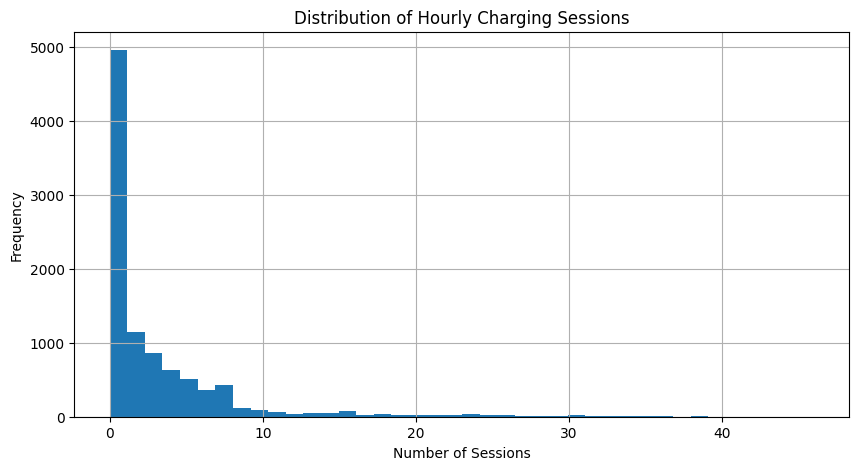

In [36]:
# demand distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
hourly_demand['num_sessions'].hist(bins=40)
plt.title('Distribution of Hourly Charging Sessions')
plt.xlabel('Number of Sessions')
plt.ylabel('Frequency')
plt.show()

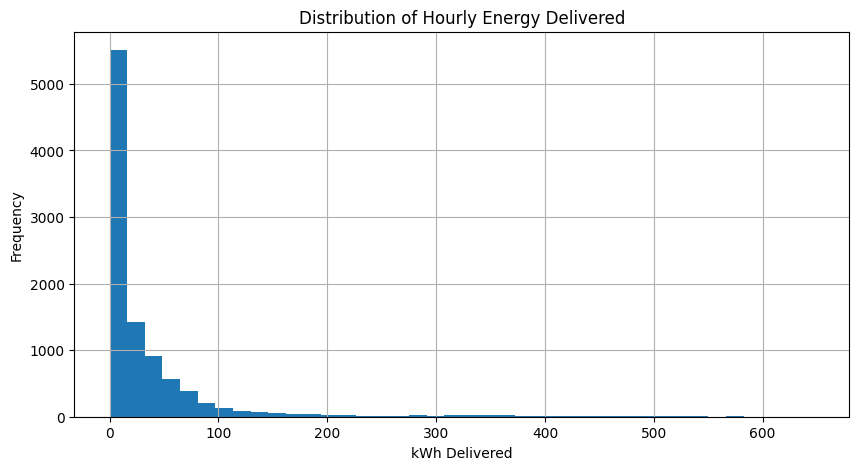

In [37]:
# energy level distribution
plt.figure(figsize=(10,5))
hourly_demand['kWhDelivered'].hist(bins=40)
plt.title('Distribution of Hourly Energy Delivered')
plt.xlabel('kWh Delivered')
plt.ylabel('Frequency')
plt.show()

Index(['connectionTime', 'kWhDelivered', 'num_sessions', 'utilization_ratio',
       'baseline_revenue', 'hour', 'day_of_week', 'month', 'weekend'],
      dtype='object')


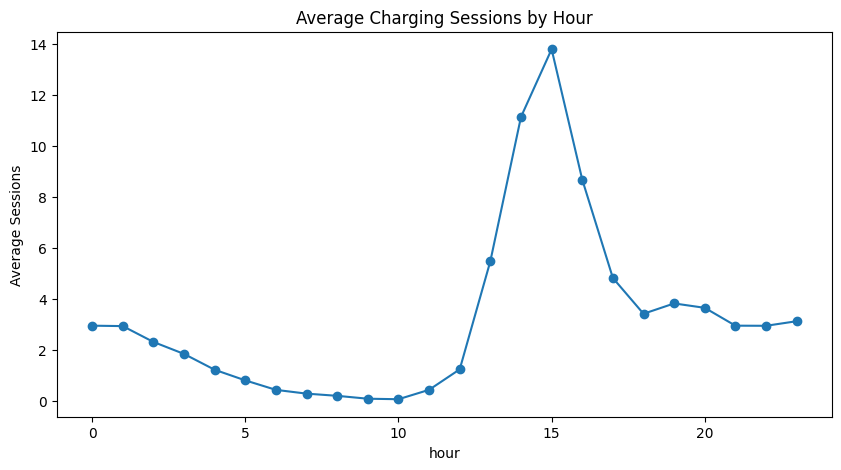

In [39]:
# average demand by hour
# Add time features

hourly_demand['hour'] = hourly_demand['connectionTime'].dt.hour

hourly_demand['day_of_week'] = (
    hourly_demand['connectionTime'].dt.dayofweek
)

hourly_demand['month'] = (
    hourly_demand['connectionTime'].dt.month
)

hourly_demand['weekend'] = (
    hourly_demand['day_of_week'].isin([5,6])
).astype(int)

print(hourly_demand.columns)
hourly_demand.groupby('hour')['num_sessions'].mean().plot(
    figsize=(10,5),
    marker='o'
)

plt.title('Average Charging Sessions by Hour')
plt.ylabel('Average Sessions')
plt.show()

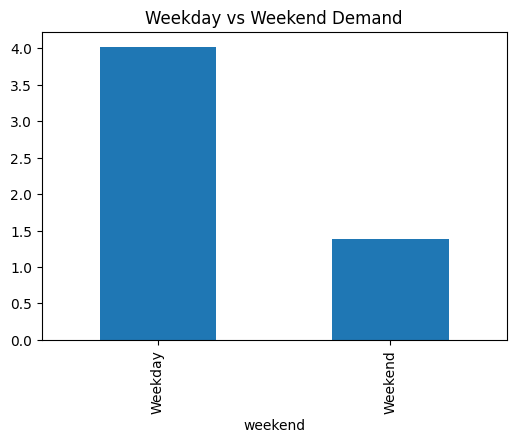

In [40]:
# weekwnd vs weekdays demand
hourly_demand.groupby('weekend')['num_sessions'].mean().plot(
    kind='bar',
    figsize=(6,4)
)

plt.title('Weekday vs Weekend Demand')
plt.xticks([0,1], ['Weekday','Weekend'])
plt.show()

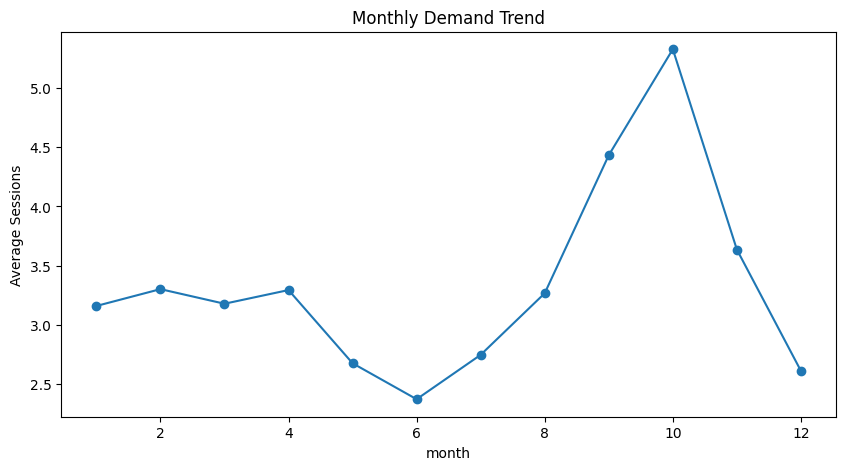

In [41]:
# monthly demand trend
hourly_demand.groupby('month')['num_sessions'].mean().plot(
    figsize=(10,5),
    marker='o'
)

plt.title('Monthly Demand Trend')
plt.ylabel('Average Sessions')
plt.show()

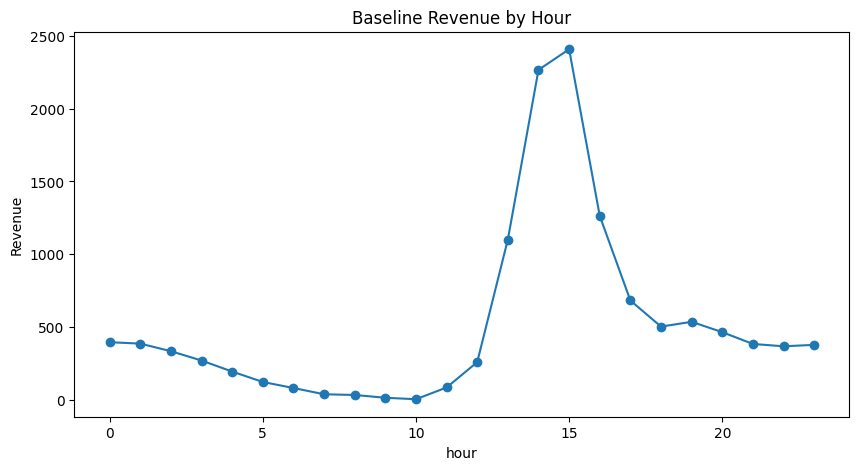

In [42]:
# revenue by hour
hourly_demand.groupby('hour')['baseline_revenue'].mean().plot(
    figsize=(10,5),
    marker='o'
)

plt.title('Baseline Revenue by Hour')
plt.ylabel('Revenue')
plt.show()

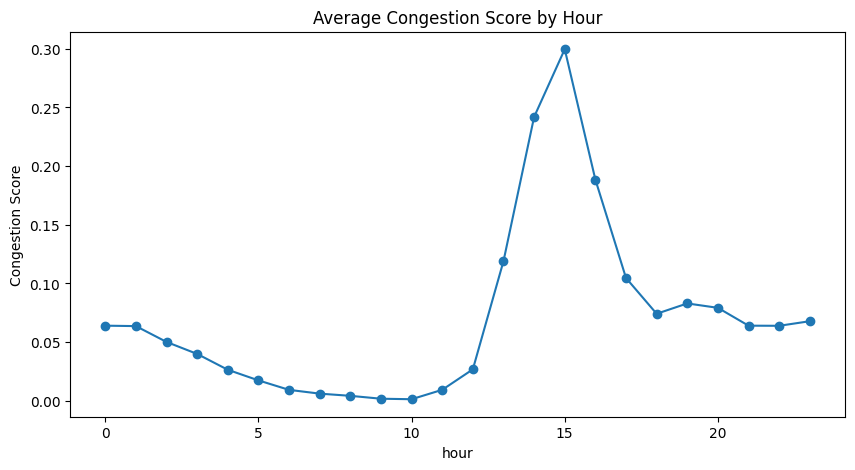

In [44]:
# congestion analysis
# Congestion Score (0 to 1)

hourly_demand['congestion_score'] = (
    hourly_demand['num_sessions']
    / hourly_demand['num_sessions'].max()
)

hourly_demand[['num_sessions','congestion_score']].head()
hourly_demand.groupby('hour')['congestion_score'].mean().plot(
    figsize=(10,5),
    marker='o'
)

plt.title('Average Congestion Score by Hour')
plt.ylabel('Congestion Score')
plt.show()

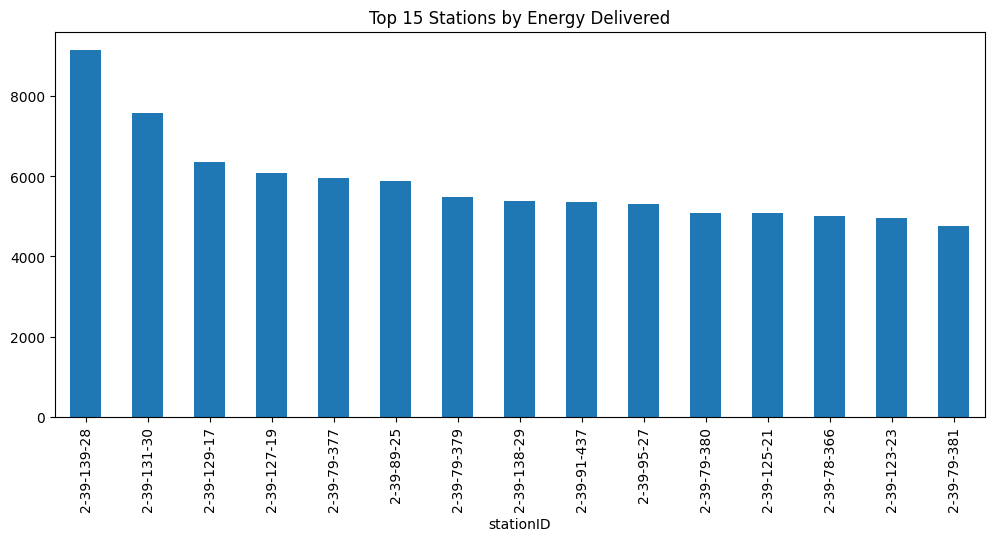

In [45]:
# top charging stations
top_stations = acn_df.groupby(
    'stationID'
)['kWhDelivered'].sum().sort_values(
    ascending=False
).head(15)

top_stations.plot(
    kind='bar',
    figsize=(12,5)
)

plt.title('Top 15 Stations by Energy Delivered')
plt.show()

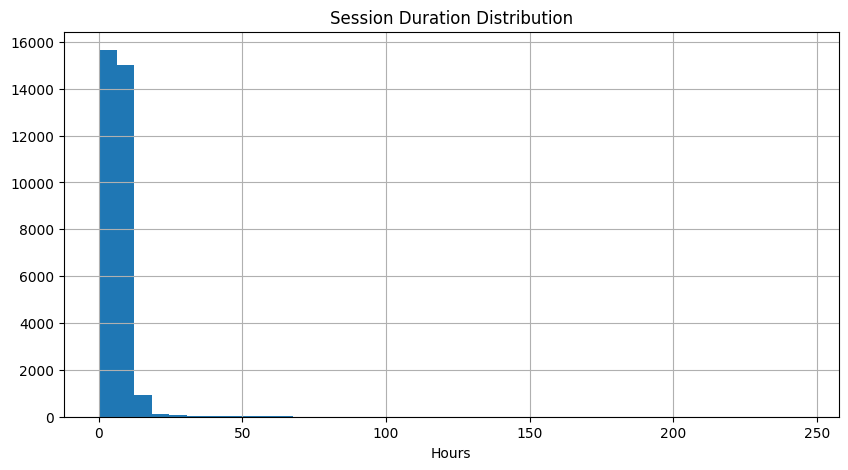

In [46]:
# session duration distribution
plt.figure(figsize=(10,5))
acn_df['session_duration_hr'].hist(
    bins=40
)

plt.title('Session Duration Distribution')
plt.xlabel('Hours')
plt.show()

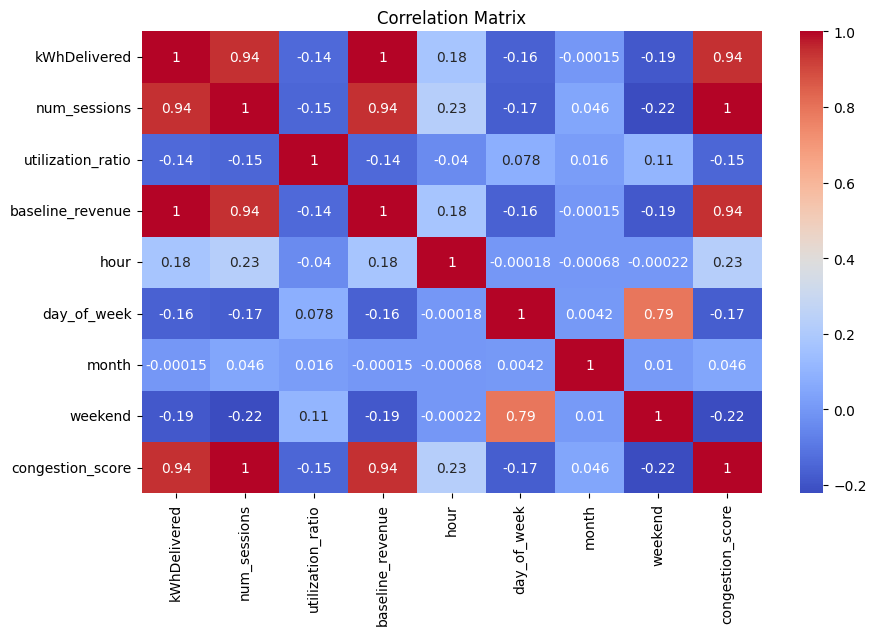

In [47]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(
    hourly_demand.select_dtypes(
        include='number'
    ).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.show()

In [50]:
# Sort chronologically
hourly_demand = hourly_demand.sort_values(
    'connectionTime'
).reset_index(drop=True)

# Lag Features
hourly_demand['lag_1'] = hourly_demand['num_sessions'].shift(1)
hourly_demand['lag_24'] = hourly_demand['num_sessions'].shift(24)
hourly_demand['lag_168'] = hourly_demand['num_sessions'].shift(168)

# Rolling Features
hourly_demand['rolling_mean_24'] = (
    hourly_demand['num_sessions']
    .rolling(window=24)
    .mean()
)

hourly_demand['rolling_std_24'] = (
    hourly_demand['num_sessions']
    .rolling(window=24)
    .std()
)

hourly_demand.dropna(inplace=True)

print(hourly_demand.shape)

(6216, 16)


In [51]:
# train test split
features = [
    'hour',
    'day_of_week',
    'month',
    'weekend',
    'lag_1',
    'lag_24',
    'lag_168',
    'rolling_mean_24',
    'rolling_std_24'
]

X = hourly_demand[features]

y = hourly_demand['num_sessions']

split_idx = int(len(hourly_demand) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

In [52]:
# Random forest baseline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = mean_squared_error(
    y_test,
    pred_rf
) ** 0.5

r2_rf = r2_score(
    y_test,
    pred_rf
)

print("RF MAE:", mae_rf)
print("RF RMSE:", rmse_rf)
print("RF R2:", r2_rf)

RF MAE: 2.652905948553055
RF RMSE: 4.724799271412987
RF R2: 0.44722456852607495


In [53]:
!pip install xgboost -q

In [54]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, pred_xgb)
rmse_xgb = mean_squared_error(
    y_test,
    pred_xgb
) ** 0.5

r2_xgb = r2_score(
    y_test,
    pred_xgb
)

print("XGB MAE:", mae_xgb)
print("XGB RMSE:", rmse_xgb)
print("XGB R2:", r2_xgb)

XGB MAE: 2.5874764919281006
XGB RMSE: 4.435049750598431
XGB R2: 0.5129439830780029


In [55]:
hourly_demand['lag_2'] = hourly_demand['num_sessions'].shift(2)
hourly_demand['lag_3'] = hourly_demand['num_sessions'].shift(3)

hourly_demand['lag_48'] = hourly_demand['num_sessions'].shift(48)
hourly_demand['lag_72'] = hourly_demand['num_sessions'].shift(72)
hourly_demand['rolling_mean_168'] = (
    hourly_demand['num_sessions']
    .rolling(168)
    .mean()
)

hourly_demand['rolling_std_168'] = (
    hourly_demand['num_sessions']
    .rolling(168)
    .std()
)
import numpy as np

hourly_demand['sin_hour'] = np.sin(
    2*np.pi*hourly_demand['hour']/24
)

hourly_demand['cos_hour'] = np.cos(
    2*np.pi*hourly_demand['hour']/24
)

hourly_demand['sin_day'] = np.sin(
    2*np.pi*hourly_demand['day_of_week']/7
)

hourly_demand['cos_day'] = np.cos(
    2*np.pi*hourly_demand['day_of_week']/7
)
hourly_demand['prev_day_mean'] = (
    hourly_demand['num_sessions']
    .shift(24)
    .rolling(24)
    .mean()
)

hourly_demand['prev_week_mean'] = (
    hourly_demand['num_sessions']
    .shift(168)
    .rolling(168)
    .mean()
)
hourly_demand['lag_energy_24'] = (
    hourly_demand['kWhDelivered']
    .shift(24)
)

hourly_demand['lag_energy_168'] = (
    hourly_demand['kWhDelivered']
    .shift(168)
)
xgb = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=10,
    min_child_weight=3,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0.1,
    random_state=42
)

In [56]:
# Remove rows created with NaNs from new lag features
hourly_demand_model = hourly_demand.copy()

hourly_demand_model = hourly_demand_model.dropna()

print(hourly_demand_model.shape)


(5881, 30)


In [58]:
features = [
    'hour',
    'day_of_week',
    'month',
    'weekend',

    'lag_1',
    'lag_2',
    'lag_3',
    'lag_24',
    'lag_48',
    'lag_72',
    'lag_168',

    'rolling_mean_24',
    'rolling_std_24',
    'rolling_mean_168',
    'rolling_std_168',

    'prev_day_mean',
    'prev_week_mean',

    'lag_energy_24',
    'lag_energy_168',

    'sin_hour',
    'cos_hour',
    'sin_day',
    'cos_day'
]

X = hourly_demand_model[features]
y = hourly_demand_model['num_sessions']
split_idx = int(len(hourly_demand_model) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]


In [59]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

xgb = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=10,
    min_child_weight=3,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0.1,
    random_state=42
)

xgb.fit(X_train, y_train)

pred = xgb.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = mean_squared_error(y_test, pred) ** 0.5
r2 = r2_score(y_test, pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 2.0267369747161865
RMSE: 3.2231279247626468
R2  : 0.7381947040557861


TRAFFIC PRICING AGENT

In [60]:
hourly_demand_model['predicted_sessions'] = xgb.predict(X)

In [61]:
# tariff rules:
def dynamic_tariff(pred_sessions):

    if pred_sessions >= 12:
        return 18   # Surge

    elif pred_sessions >= 8:
        return 16

    elif pred_sessions >= 4:
        return 15

    else:
        return 12   # Discount

hourly_demand_model['dynamic_tariff'] = (
    hourly_demand_model['predicted_sessions']
    .apply(dynamic_tariff)
)

# revenue stimulation
hourly_demand_model['baseline_revenue'] = (
    hourly_demand_model['kWhDelivered'] * 15
)

hourly_demand_model['dynamic_revenue'] = (
    hourly_demand_model['kWhDelivered']
    * hourly_demand_model['dynamic_tariff']
)



In [62]:
# calculating project KPI
baseline = hourly_demand_model['baseline_revenue'].sum()

dynamic = hourly_demand_model['dynamic_revenue'].sum()

revenue_gain = (
    (dynamic - baseline)
    / baseline
) * 100

print("Baseline Revenue:", baseline)
print("Dynamic Revenue:", dynamic)
print("Revenue Gain %:", revenue_gain)

Baseline Revenue: 4853822.569488255
Dynamic Revenue: 5110067.636539124
Revenue Gain %: 5.279242563616925


In [65]:
# ==========================================
# TARIFF STRATEGY 1 : Rule-Based (Current)
# ==========================================

def tariff_v1(pred):

    if pred >= 12:
        return 18

    elif pred >= 8:
        return 16

    elif pred >= 4:
        return 15

    else:
        return 12

hourly_demand_model['tariff_v1'] = (
    hourly_demand_model['predicted_sessions']
    .apply(tariff_v1)
)

hourly_demand_model['revenue_v1'] = (
    hourly_demand_model['kWhDelivered']
    * hourly_demand_model['tariff_v1']
)

# ==========================================
# TARIFF STRATEGY 2 : Aggressive
# ==========================================

def tariff_v2(pred):

    if pred >= 14:
        return 20

    elif pred >= 10:
        return 18

    elif pred >= 6:
        return 15

    else:
        return 11

hourly_demand_model['tariff_v2'] = (
    hourly_demand_model['predicted_sessions']
    .apply(tariff_v2)
)

hourly_demand_model['revenue_v2'] = (
    hourly_demand_model['kWhDelivered']
    * hourly_demand_model['tariff_v2']
)

# ==========================================
# TARIFF STRATEGY 3 : Percentile-Based
# ==========================================

q25 = hourly_demand_model['predicted_sessions'].quantile(0.25)
q50 = hourly_demand_model['predicted_sessions'].quantile(0.50)
q75 = hourly_demand_model['predicted_sessions'].quantile(0.75)

def tariff_v3(pred):

    if pred >= q75:
        return 20

    elif pred >= q50:
        return 17

    elif pred >= q25:
        return 15

    else:
        return 11

hourly_demand_model['tariff_v3'] = (
    hourly_demand_model['predicted_sessions']
    .apply(tariff_v3)
)

hourly_demand_model['revenue_v3'] = (
    hourly_demand_model['kWhDelivered']
    * hourly_demand_model['tariff_v3']
)

# ==========================================
# Revenue Comparison
# ==========================================

baseline = (
    hourly_demand_model['baseline_revenue']
    .sum()
)

rev1 = hourly_demand_model['revenue_v1'].sum()
rev2 = hourly_demand_model['revenue_v2'].sum()
rev3 = hourly_demand_model['revenue_v3'].sum()

gain1 = ((rev1 - baseline)/baseline)*100
gain2 = ((rev2 - baseline)/baseline)*100
gain3 = ((rev3 - baseline)/baseline)*100

comparison = pd.DataFrame({
    'Strategy': [
        'Baseline',
        'Rule Based',
        'Aggressive',
        'Percentile'
    ],
    'Revenue': [
        baseline,
        rev1,
        rev2,
        rev3
    ],
    'Revenue Gain %': [
        0,
        gain1,
        gain2,
        gain3
    ]
})

print(comparison)

comparison

     Strategy       Revenue  Revenue Gain %
0    Baseline  4.853823e+06        0.000000
1  Rule Based  5.110068e+06        5.279243
2  Aggressive  5.127212e+06        5.632466
3  Percentile  5.968017e+06       22.954994


,Strategy,Revenue,Revenue Gain %
0,Baseline,4.853823e+06,0.000000
1,Rule Based,5.110068e+06,5.279243
2,Aggressive,5.127212e+06,5.632466
3,Percentile,5.968017e+06,22.954994


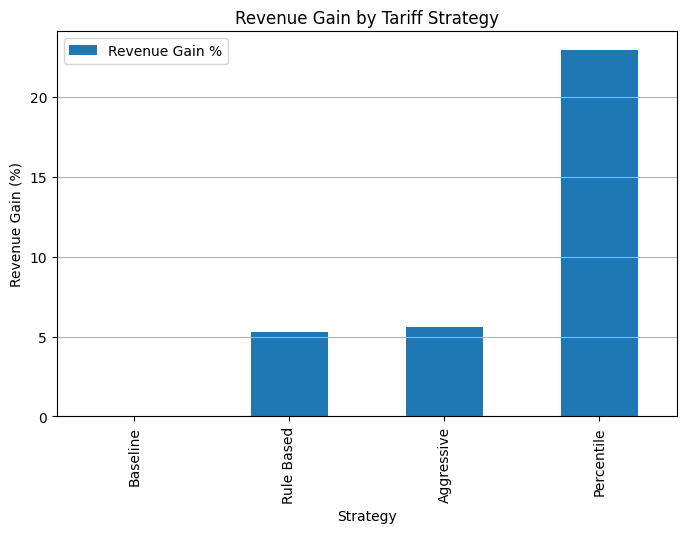

In [66]:
import matplotlib.pyplot as plt

comparison.plot(
    x='Strategy',
    y='Revenue Gain %',
    kind='bar',
    figsize=(8,5)
)

plt.title('Revenue Gain by Tariff Strategy')
plt.ylabel('Revenue Gain (%)')
plt.grid(axis='y')

plt.show()

MONITORING AGENT

In [67]:
# Final Revenue

baseline_revenue = hourly_demand_model['baseline_revenue'].sum()

dynamic_revenue = hourly_demand_model['revenue_v3'].sum()

revenue_gain_pct = (
    (dynamic_revenue - baseline_revenue)
    / baseline_revenue
) * 100

# Pricing Efficiency

pricing_efficiency = (
    dynamic_revenue
    / hourly_demand_model['kWhDelivered'].sum()
)

# Average Utilization

avg_utilization = (
    hourly_demand_model['utilization_ratio']
    .mean()
)

# Average Congestion

avg_congestion = (
    hourly_demand_model['congestion_score']
    .mean()
)

monitoring_metrics = pd.DataFrame({
    'Metric': [
        'Baseline Revenue',
        'Dynamic Revenue',
        'Revenue Gain %',
        'Pricing Efficiency',
        'Average Utilization',
        'Average Congestion'
    ],
    'Value': [
        baseline_revenue,
        dynamic_revenue,
        revenue_gain_pct,
        pricing_efficiency,
        avg_utilization,
        avg_congestion
    ]
})

monitoring_metrics

,Metric,Value
0,Baseline Revenue,4.853823e+06
1,Dynamic Revenue,5.968017e+06
2,Revenue Gain %,2.295499e+01
3,Pricing Efficiency,1.844325e+01
4,Average Utilization,7.016667e-01
5,Average Congestion,1.103184e-01


In [68]:
# learning feedback loop
def learning_signal(gain):

    if gain > 15:
        return "KEEP CURRENT POLICY"

    elif gain > 5:
        return "MINOR OPTIMIZATION"

    else:
        return "RETRAIN PRICING AGENT"

signal = learning_signal(revenue_gain_pct)

print("Learning Agent Decision:", signal)

Learning Agent Decision: KEEP CURRENT POLICY


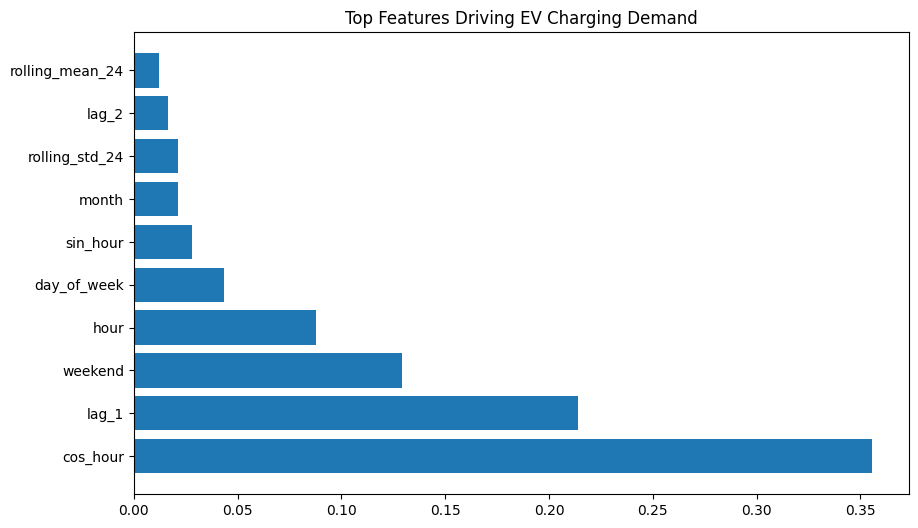

In [69]:
# Feature Importance
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'Feature': features,
    'Importance': xgb.feature_importances_
})

importance = importance.sort_values(
    'Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    importance['Feature'][:10],
    importance['Importance'][:10]
)

plt.title(
    'Top Features Driving EV Charging Demand'
)

plt.show()

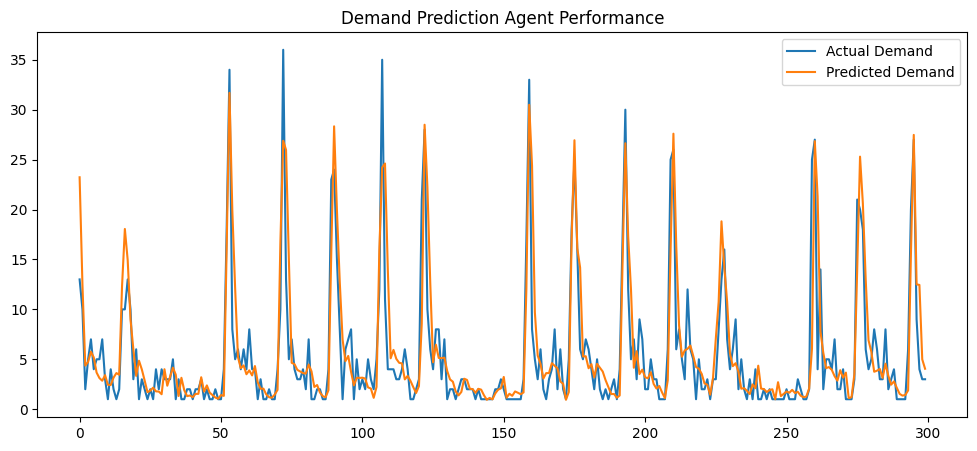

In [70]:
plt.figure(figsize=(12,5))

plt.plot(
    y_test.values[:300],
    label='Actual Demand'
)

plt.plot(
    pred[:300],
    label='Predicted Demand'
)

plt.legend()

plt.title(
    'Demand Prediction Agent Performance'
)

plt.show()

In [71]:
results = pd.DataFrame({
    "Metric":[
        "R² Score",
        "RMSE",
        "MAE",
        "Revenue Gain %",
        "Pricing Efficiency",
        "Average Utilization"
    ],
    "Value":[
        0.738,
        3.223,
        2.027,
        22.95,
        18.44,
        70.17
    ]
})

results

,Metric,Value
0,R² Score,0.738
1,RMSE,3.223
2,MAE,2.027
3,Revenue Gain %,22.950
4,Pricing Efficiency,18.440
5,Average Utilization,70.170


In [72]:
results.to_csv(
    "final_results.csv",
    index=False
)

In [75]:
!git clone https://github.com/IntelligentSystemsLab/ST-EVCDP.git

Cloning into 'ST-EVCDP'...
remote: Enumerating objects: 189, done.
remote: Counting objects: 100% (90/90), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 189 (delta 78), reused 61 (delta 61), pack-reused 99 (from 1)
Receiving objects: 100% (189/189), 12.25 MiB | 16.27 MiB/s, done.
Resolving deltas: 100% (93/93), done.


In [76]:
import os

path = "/kaggle/working/ST-EVCDP/datasets"

print(os.listdir(path))

['SZweather20220619-20220718.xls', 'information.csv', 'adj.csv', 'time.csv', 'occupancy.csv', 'Shenzhen.qgz', 'stations.csv', 'SZ_districts', 'volume.csv', 'price.csv', 'SZweather_Header.txt', 'duration.csv', 'distance.csv']


In [77]:
import pandas as pd

path = "/kaggle/working/ST-EVCDP/datasets/"

occupancy = pd.read_csv(path + "occupancy.csv")

print("Shape:", occupancy.shape)

occupancy.head()

Shape: (8640, 248)


,timestamp,102,105,107,108,109,110,111,115,123,...,1160,1162,1163,1164,1166,1167,1168,1170,1172,1173
0,1,12,16,24,15,6,8,24,1,2,...,0,12,1,38,26,162,10,1,8,15
1,2,12,16,24,15,6,8,24,1,2,...,0,12,1,38,26,162,10,1,8,15
2,3,12,16,24,15,6,8,24,1,2,...,0,12,1,38,26,164,10,1,8,15
3,4,12,16,24,15,6,8,24,1,2,...,0,12,1,38,26,166,10,1,8,15
4,5,12,16,24,15,6,8,24,1,2,...,0,12,1,38,26,168,10,1,8,15


In [78]:
import pandas as pd

path = "/kaggle/working/ST-EVCDP/datasets/"

for file in ["volume.csv", "duration.csv", "price.csv"]:
    
    print("\n" + "="*60)
    print(file)

    df = pd.read_csv(path + file)

    print("Shape:", df.shape)
    print(df.head())


volume.csv
Shape: (8640, 248)
   timestamp       102       105       107    108       109       110  \
0          1  2.858333  5.907222  6.478889  5.145  2.286667  3.048889   
1          2  4.375000  9.041667  9.916667  7.875  3.500000  4.666667   
2          3  4.375000  9.041667  9.916667  7.875  3.500000  4.666667   
3          4  4.375000  9.041667  9.916667  7.875  3.500000  4.666667   
4          5  4.375000  9.041667  9.916667  7.875  3.500000  4.666667   

        111       115       123  ...  1160      1162      1163       1164  \
0  5.526111  0.381111  0.762222  ...   0.0  2.286667  0.381111  12.195556   
1  8.458333  0.583333  1.166667  ...   0.0  3.500000  0.583333  18.666667   
2  8.458333  0.583333  1.166667  ...   0.0  3.500000  0.583333  18.666667   
3  8.458333  0.583333  1.166667  ...   0.0  3.500000  0.583333  18.666667   
4  8.458333  0.583333  1.166667  ...   0.0  3.500000  0.583333  18.666667   

        1166        1167      1168      1170      1172      1173  


In [79]:
import pandas as pd

path = "/kaggle/working/ST-EVCDP/datasets/"

occupancy = pd.read_csv(path + "occupancy.csv")
volume = pd.read_csv(path + "volume.csv")
duration = pd.read_csv(path + "duration.csv")
price = pd.read_csv(path + "price.csv")

urban_summary = pd.DataFrame()

urban_summary["timestamp"] = occupancy["timestamp"]

urban_summary["avg_occupancy"] = occupancy.drop(
    columns=["timestamp"]
).mean(axis=1)

urban_summary["avg_volume"] = volume.drop(
    columns=["timestamp"]
).mean(axis=1)

urban_summary["avg_duration"] = duration.drop(
    columns=["timestamp"]
).mean(axis=1)

urban_summary["avg_price"] = price.drop(
    columns=["timestamp"]
).mean(axis=1)

print(urban_summary.shape)

urban_summary.head()

(8640, 5)


,timestamp,avg_occupancy,avg_volume,avg_duration,avg_price
0,1,24.352227,25.161886,1.097045,0.911018
1,2,24.356275,38.514720,1.679383,0.911018
2,3,24.643725,40.093327,1.689265,0.911018
3,4,24.923077,44.544098,1.726874,0.911018
4,5,25.072874,46.450680,1.743640,0.911018


In [80]:
urban_summary.describe()

,timestamp,avg_occupancy,avg_volume,avg_duration,avg_price
count,8640.000000,8640.000000,8640.000000,8640.000000,8640.000000
mean,4320.500000,21.902044,36.678448,1.472631,0.958571
std,2494.297496,3.490632,11.344384,0.294946,0.036715
min,1.000000,15.967611,18.007422,0.968961,0.907414
25%,2160.750000,18.793522,27.232143,1.202534,0.913539
50%,4320.500000,21.607287,33.736693,1.448718,0.964566
75%,6480.250000,25.259109,46.712247,1.760588,0.988878
max,8640.000000,31.518219,65.827530,2.048920,1.021620


# UrbanEV Dataset Analysis

The UrbanEV dataset was used to validate charging demand patterns, occupancy trends, charging duration behavior, and electricity pricing variations observed in ACN-Data.

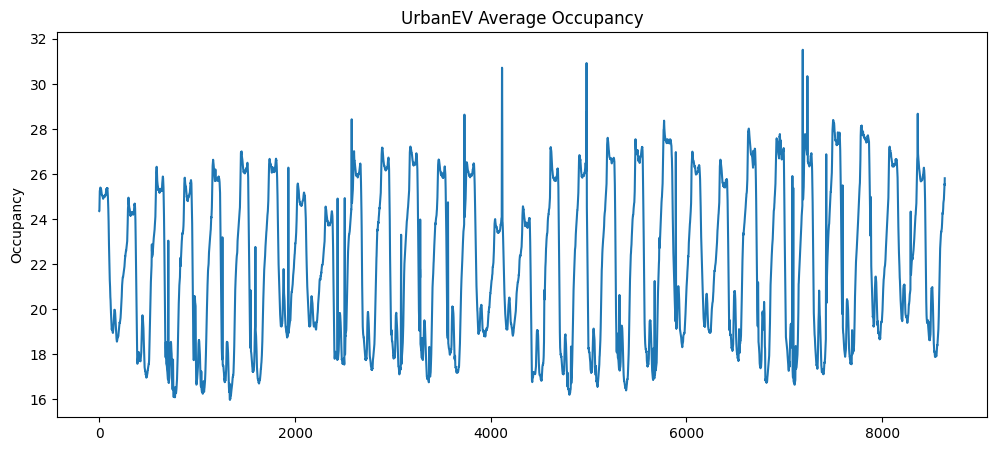

In [81]:
# occupancy trend
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

urban_summary['avg_occupancy'].plot()

plt.title('UrbanEV Average Occupancy')
plt.ylabel('Occupancy')

plt.show()

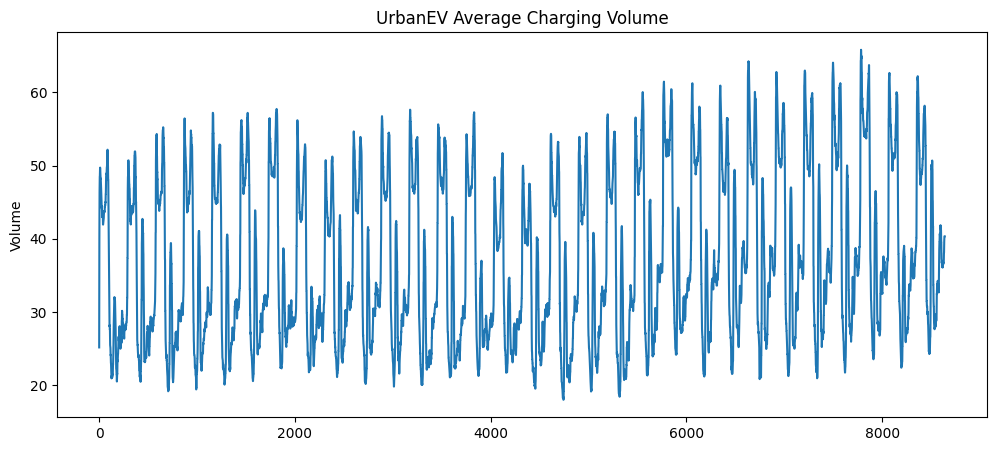

In [82]:
# charging vilumes
plt.figure(figsize=(12,5))

urban_summary['avg_volume'].plot()

plt.title('UrbanEV Average Charging Volume')
plt.ylabel('Volume')

plt.show()

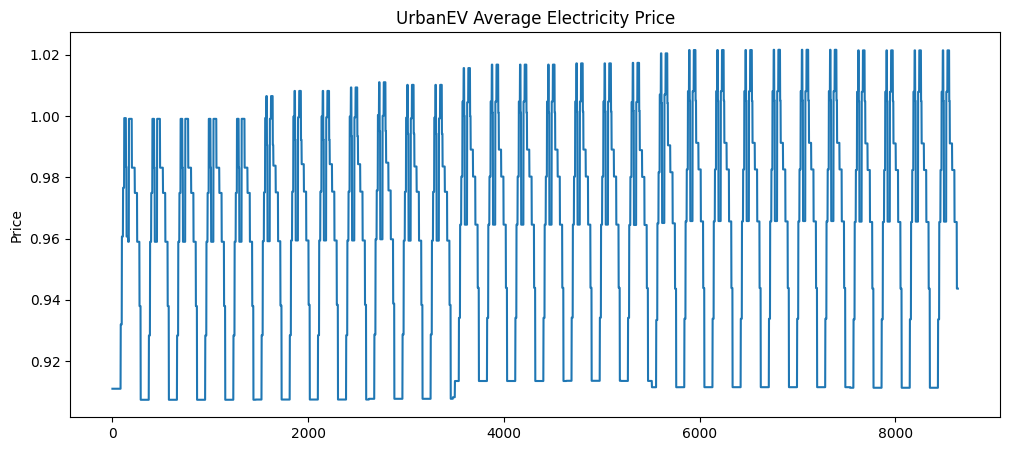

In [83]:
# electricity prices
plt.figure(figsize=(12,5))

urban_summary['avg_price'].plot()

plt.title('UrbanEV Average Electricity Price')
plt.ylabel('Price')

plt.show()

In [84]:
# station utilization analysis
station_analysis = acn_df.groupby(
    'stationID'
).agg({
    'utilization_ratio':'mean',
    'kWhDelivered':'sum',
    'sessionID':'count'
})

station_analysis.columns = [
    'avg_utilization',
    'total_energy',
    'total_sessions'
]

station_analysis.sort_values(
    'avg_utilization',
    ascending=False
).head(10)

,avg_utilization,total_energy,total_sessions
stationID,,,
2-39-78-362,0.998122,2426.145364,307
2-39-83-387,0.787775,461.667000,73
2-39-128-18,0.758671,3749.688348,466
2-39-126-20,0.758463,3245.758000,409
2-39-130-31,0.748530,4534.003652,559
2-39-138-29,0.740493,5378.160058,653
1-1-194-826,0.734157,4670.749638,263
2-39-78-361,0.734016,2817.369836,380
1-1-193-825,0.733495,4180.374865,285
